<a href="https://colab.research.google.com/github/ArtemkaGh0st1k/TechArtInt/blob/feature%2Flab1/lab1/VasilevAS_6231_TAI_Lab1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Васильев Артём
# Группа 6231
# Вариант 1
# Лабораторная работа 1

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
import sys

PROJECT_PATH = '/content/drive/MyDrive/Магистратура/3й сем/Технологии искусственного интелекта'
sys.path.append(PROJECT_PATH)
sys.path.append(f"{PROJECT_PATH}/scripts")

if not os.path.exists(PROJECT_PATH):
  print("Путь не найден!")
else:
  os.chdir(PROJECT_PATH)
  print("Текущая рабочая директория:", os.getcwd())



Текущая рабочая директория: /content/drive/MyDrive/Магистратура/3й сем/Технологии искусственного интелекта


- Классификация данных методом k ближайших соседей ( kNN)

- Классификация данных методом опорных векторов (SVM)

`Вариант 1` : задания `1` и `2` на наборе данных `CIFAR-10`


## 1. Классификация данных методом k ближайших соседей ( kNN)

In [3]:
import random
import numpy as np
import matplotlib.pyplot as plt
from lab_1_2.scripts.data_utils import load_CIFAR10


%matplotlib inline
plt.rcParams['figure.figsize'] = (10.0, 8.0)
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'

1.1 Скачайте данные в соответсвии с заданием.

CIFAR-10 по ссылке https://www.cs.toronto.edu/~kriz/cifar.html
или используйте  команду !bash get_datasets.sh (google colab, local ubuntu)

MNIST
sklearn.datasets import load_digits
digits = load_digits()

In [ ]:
#!bash lab_1_2/scripts/datasets/get_datasets.sh --> загружено

In [4]:
cifar10_dir = 'cifar-10-batches-py'

try:
   del X_train, y_train
   del X_test, y_test
   print('Clear previously loaded data.')
except:
   pass

X_train, y_train, X_test, y_test = load_CIFAR10(cifar10_dir)

print('Training data shape: ', X_train.shape)
print('Training labels shape: ', y_train.shape)
print('Test data shape: ', X_test.shape)
print('Test labels shape: ', y_test.shape)

Training data shape:  (50000, 32, 32, 3)
Training labels shape:  (50000,)
Test data shape:  (10000, 32, 32, 3)
Test labels shape:  (10000,)


1.2 Выведите несколько примеров изображений из обучающей выборки для каждого класса.



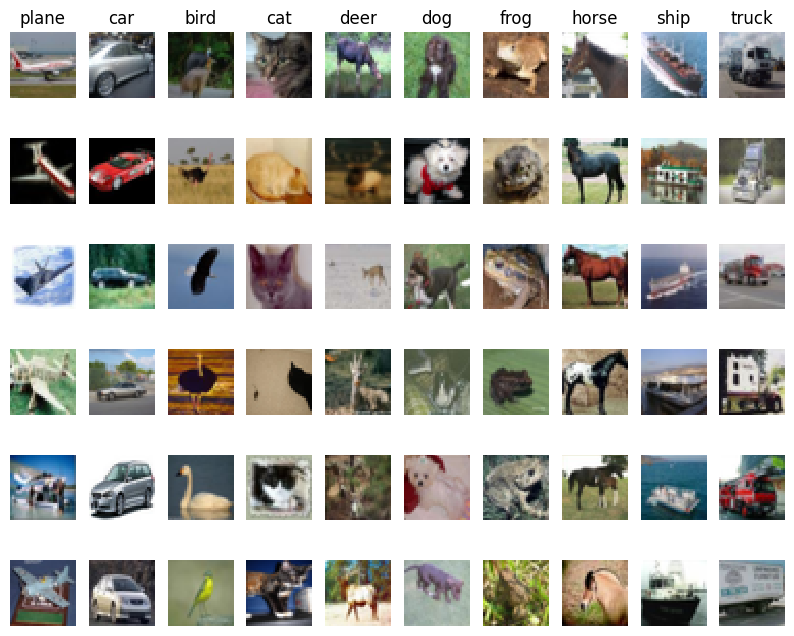

In [ ]:
classes = ['plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse',
           'ship', 'truck']
num_classes = len(classes)
sample_per_class = 6

for y, cls in enumerate(classes):
    # находим индексы всех изображений текущего класса
    idxs = np.flatnonzero(y_train == y)
    # выбираем случайные индексы
    idxs = np.random.choice(idxs, sample_per_class, replace=False)

    for i, idx in enumerate(idxs):
        plt_idx = i * num_classes + y + 1
        plt.subplot(sample_per_class, num_classes, plt_idx)

        plt.imshow(X_train[idx].astype('uint8'))
        plt.axis('off')

        if i == 0:
            plt.title(cls)

plt.show()

1.3 Разделите данные на обучающу и тестовую выборки (X_train, y_train, X_test, y_test). Преобразуйте каждое изображение в одномерный массив.

In [ ]:
X_train = X_train.reshape(X_train.shape[0], -1)
X_test = X_test.reshape(X_test.shape[0], -1)

print('Обучающая выборка X_train:', X_train.shape)
print('Метки обучения y_train:', y_train.shape)
print('Тестовая выборка X_test:', X_test.shape)
print('Метки теста y_test:', y_test.shape)

Обучающая выборка X_train: (50000, 3072)
Метки обучения y_train: (50000,)
Тестовая выборка X_test: (10000, 3072)
Метки теста y_test: (10000,)


Реализация класса KNearestNeighbor из модуля k_nearest_neighbor

In [ ]:
from builtins import range
from builtins import object
import numpy as np
from past.builtins import xrange


class KNearestNeighbor(object):
    """ a kNN classifier with L2 distance """

    def __init__(self):
        pass

    def train(self, X, y):
        """
        Train the classifier. For k-nearest neighbors this is just
        memorizing the training data.

        Inputs:
        - X: A numpy array of shape (num_train, D) containing the training data
          consisting of num_train samples each of dimension D.
        - y: A numpy array of shape (N,) containing the training labels, where
             y[i] is the label for X[i].
        """

        self.X_train = X
        self.y_train = y

    def predict(self, X, k=1, num_loops=0):
        """
        Predict labels for test data using this classifier.

        Inputs:
        - X: A numpy array of shape (num_test, D) containing test data consisting
             of num_test samples each of dimension D.
        - k: The number of nearest neighbors that vote for the predicted labels.
        - num_loops: Determines which implementation to use to compute distances
          between training points and testing points.

        Returns:
        - y: A numpy array of shape (num_test,) containing predicted labels for the
          test data, where y[i] is the predicted label for the test point X[i].
        """

        if num_loops == 0:
            dists = self.compute_distances_no_loops(X)
        elif num_loops == 1:
            dists = self.compute_distances_one_loop(X)
        elif num_loops == 2:
            dists = self.compute_distances_two_loops(X)
        else:
            raise ValueError('Invalid value %d for num_loops' % num_loops)

        return self.predict_labels(dists, k=k)

    def compute_distances_two_loops(self, X):
        """
        Compute the distance between each test point in X and each training point
        in self.X_train using a nested loop over both the training data and the
        test data.

        Inputs:
        - X: A numpy array of shape (num_test, D) containing test data.

        Returns:
        - dists: A numpy array of shape (num_test, num_train) where dists[i, j]
          is the Euclidean distance between the ith test point and the jth training
          point.
        """

        num_test = X.shape[0]
        num_train = self.X_train.shape[0]
        dists = np.zeros((num_test, num_train))
        for i in range(num_test):
            for j in range(num_train):
                dists[i, j] = np.sqrt(np.sum((X[i] - self.X_train[j]) ** 2))

        return dists

    def compute_distances_one_loop(self, X):
        """
        Compute the distance between each test point in X and each training point
        in self.X_train using a single loop over the test data.

        Input / Output: Same as compute_distances_two_loops
        """

        num_test = X.shape[0]
        num_train = self.X_train.shape[0]
        dists = np.zeros((num_test, num_train))
        for i in range(num_test):
            dists[i, :] = np.sqrt(np.sum((self.X_train - X[i]) **2 ), axis=1)

        return dists

    def compute_distances_no_loops(self, X):
        """
        Compute the distance between each test point in X and each training point
        in self.X_train using no explicit loops.

        Input / Output: Same as compute_distances_two_loops
        """

        num_test = X.shape[0]
        num_train = self.X_train.shape[0]
        dists = np.zeros((num_test, num_train))

        test_sum_sq = np.sum(X ** 2, axis=1, keepdims=True)
        train_sum_sq = np.sum(self.X_train ** 2, axis=1)
        cross_term = np.dot(X, self.X_train.T)

        dists = np.sqrt(test_sum_sq + train_sum_sq - 2 * cross_term)

        return dists

    def predict_labels(self, dists, k=1):
        """
        Given a matrix of distances between test points and training points,
        predict a label for each test point.

        Inputs:
        - dists: A numpy array of shape (num_test, num_train) where dists[i, j]
          gives the distance betwen the ith test point and the jth training point.

        Returns:
        - y: A numpy array of shape (num_test,) containing predicted labels for the
          test data, where y[i] is the predicted label for the test point X[i].
        """
        num_test = dists.shape[0]
        y_pred = np.zeros(num_test)
        for i in range(num_test):
            closest_y = []

            # находим индексы k наименьших расстояний для i-ого тестовго объекта
            k_nearest_indices = np.argsort(dists[i, :])[:k]

            # получаем метки этих соседей
            closest_y = self.y_train[k_nearest_indices]

            # находим самую частую метку (моду) с разрешением ничьей в пользу меньшей метки
            counts = np.bincount(closest_y)
            y_pred[i] = np.argmax(counts)

        return y_pred


1.4 Напишите реализацию классификатора в скрипте /classifiers/k_nearest_neighbor.py и обучите его на сформированной выборке.

In [ ]:
classifier = KNearestNeighbor()
classifier.train(X_train, y_train)

Разобьём тествовую выборку на батчи, чтобы не
было переполнения памяти

In [ ]:
def predict_in_batches(classifier : KNearestNeighbor, X_test, k=5, batch_size=500):
  """Выполняет предсказание по батчам, чтобы не переполнять ОЗУ"""

  num_test = X_test.shape[0]
  y_pred = np.zeros(num_test)

  for i in range(0, num_test, batch_size):
    X_batch = X_test[i:i + batch_size]
    # для каждого батча считаем расстояние векторизованно
    dist_batch = classifier.compute_distances_no_loops(X_batch)
    # получаем предсказания только для текущего батча
    y_pred[i:i + batch_size] = classifier.predict_labels(dist_batch, k=k)

  return y_pred

1.5 Выполните классификацию на тестовой выборке

In [ ]:
k_default = 5
y_test_pred = predict_in_batches(classifier, X_test, k=k_default, batch_size=500)
print(f"1.5: Предсказания для тестовой выборки получены (k={k_default}).")


1.5: Предсказания для тестовой выборки получены (k=5).


1.6 Визуализируйте матрицу расстояний для каждого изображения из тестовой выборки до изображений из обучающей выборки.


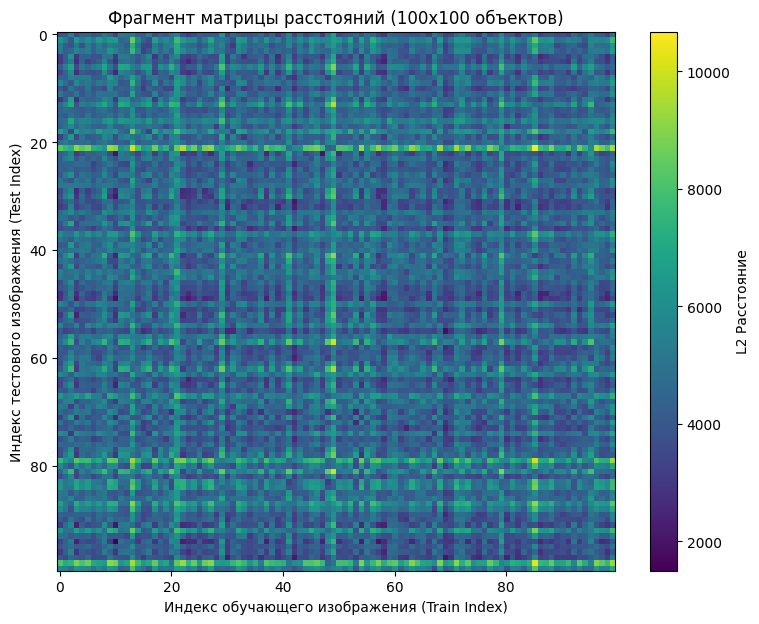

In [ ]:
num_vis = 100
dists_sub = classifier.compute_distances_no_loops(X_test[:num_vis])[:, :num_vis]

plt.figure(figsize=(9, 7))
plt.imshow(dists_sub, cmap='viridis', interpolation='none', aspect='auto')
plt.colorbar(label='L2 Расстояние')
plt.title(f'Фрагмент матрицы расстояний ({num_vis}x{num_vis} объектов)')
plt.xlabel('Индекс обучающего изображения (Train Index)')
plt.ylabel('Индекс тестового изображения (Test Index)')
plt.show()


1.7 Посчитайте долю правильно классифицированных изображений из тестовой выборки.


In [ ]:
accuracy_test = np.mean(y_test_pred == y_test)
print(f"1.7: Доля верных ответов (Accuracy) при k={k_default}: {accuracy_test * 100:.2f}%\n")

1.7: Доля верных ответов (Accuracy) при k=5: 33.98%



1.8 Постройте график зависимости доли правильно классифицированных изображений от числа соседей, используемых при классификации.

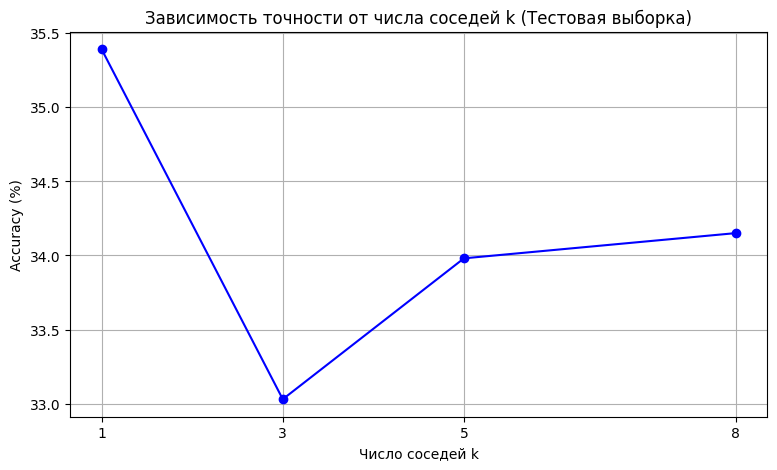

In [ ]:
k_choices = [1, 3, 5, 8]
accuracies_k = []

for k in k_choices:
    # Используем безопасное прогнозирование батчами для каждого k
    y_pred_k = predict_in_batches(classifier, X_test, k=k, batch_size=500)
    acc = np.mean(y_pred_k == y_test)
    accuracies_k.append(acc)

plt.figure(figsize=(9, 5))
plt.plot(k_choices, [a * 100 for a in accuracies_k], marker='o', color='b', linestyle='-')
plt.title('Зависимость точности от числа соседей k (Тестовая выборка)')
plt.xlabel('Число соседей k')
plt.ylabel('Accuracy (%)')
plt.xticks(k_choices)
plt.grid(True)
plt.show()

1.9 Выберите лучшее значение параметра k на основе кросс-валидации.


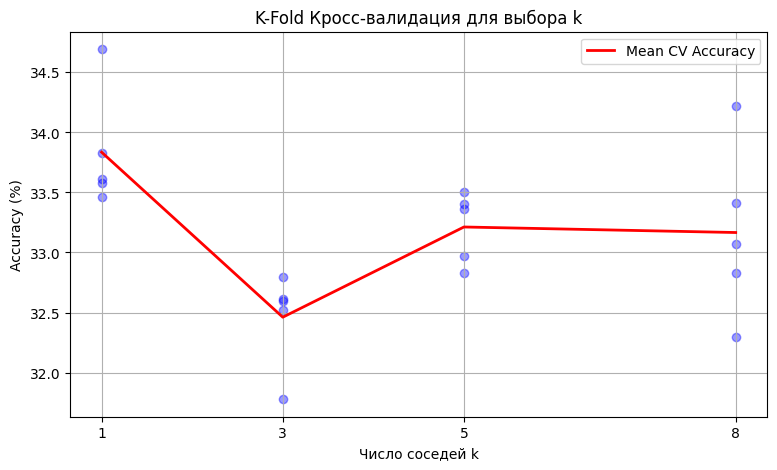

1.9: Оптимальное значение k по кросс-валидации: best_k = 1


In [ ]:
num_folds = 5
k_cv_choices = [1, 3, 5, 8]

# Разбиваем обучающие данные на 5 фолдов
X_train_folds = np.array_split(X_train, num_folds)
y_train_folds = np.array_split(y_train, num_folds)

k_to_accuracies = {k: [] for k in k_cv_choices}

for fold in range(num_folds):
    # Формируем валидационную и обучающую выборки для текущего фолда
    X_val = X_train_folds[fold]
    y_val = y_train_folds[fold]

    X_tr = np.concatenate([X_train_folds[i] for i in range(num_folds) if i != fold])
    y_tr = np.concatenate([y_train_folds[i] for i in range(num_folds) if i != fold])

    # Обучаем kNN
    knn_cv = KNearestNeighbor()
    knn_cv.train(X_tr, y_tr)

    # Оцениваем для каждого k
    for k in k_cv_choices:
        y_val_pred = predict_in_batches(knn_cv, X_val, k=k, batch_size=500)
        acc = np.mean(y_val_pred == y_val)
        k_to_accuracies[k].append(acc)

# Визуализация результатов кросс-валидации
plt.figure(figsize=(9, 5))
for k in k_cv_choices:
    plt.scatter([k] * num_folds, [a * 100 for a in k_to_accuracies[k]], color='blue', alpha=0.4)

mean_accuracies = [np.mean(k_to_accuracies[k]) for k in k_cv_choices]
plt.plot(k_cv_choices, [m * 100 for m in mean_accuracies], color='red', linewidth=2, label='Mean CV Accuracy')

plt.title('K-Fold Кросс-валидация для выбора k')
plt.xlabel('Число соседей k')
plt.ylabel('Accuracy (%)')
plt.xticks(k_cv_choices)
plt.legend()
plt.grid(True)
plt.show()

# Находим лучшее значение k
best_k = k_cv_choices[np.argmax(mean_accuracies)]
print(f"1.9: Оптимальное значение k по кросс-валидации: best_k = {best_k}")


1.10 Переобучите и протестируйте классификатор с использованием выбранного значения k.



In [ ]:
final_classifier = KNearestNeighbor()
final_classifier.train(X_train, y_train)

# Тестируем с найденным оптимальным best_k
y_test_pred_best = predict_in_batches(final_classifier, X_test, k=best_k, batch_size=500)
final_accuracy = np.mean(y_test_pred_best == y_test)

print(f"1.10: Финальная точность на тестовой выборке с best_k={best_k}: {final_accuracy * 100:.2f}%")

1.10: Финальная точность на тестовой выборке с best_k=1: 35.39%


1.11 Сделайте выводы по результатам 1 части задания.

Алгоритм kNN с $L_2$-расстоянием показал себя как базовый ориентир (baseline) с точностью ~35.4%. Главными ограничениями метода являются высокая вычислительная сложность на этапе предсказания ($O(N \cdot D)$) и нечувствительность $L_2$-метрики к семантическому содержанию изображений.

## 2.  Классификация данных методом опорных векторов (SVM)

2.1 Разделите данные на обучающую, тестовую и валидационную выборки. Преобразуйте каждое изображение в одномерный массив. Выведите размеры выборок.

In [5]:

from sklearn.model_selection import train_test_split

try:
   del X_train_svm, y_train_svm
   del X_test_svm, y_test_svm
   print('Clear previously loaded data for SVM.')
except:
   pass

X_train_svm, y_train_svm, X_test_svm, y_test_svm = load_CIFAR10(cifar10_dir)

X_train, X_val, y_train, y_val = train_test_split(
     X_train_svm, y_train_svm,
     test_size=1000,
     train_size=4900,
     random_state=42
 )

 # 1000 объектов для тестовой выборки
X_test, _, y_test, _ = train_test_split(
      X_test_svm, y_test_svm,
      train_size=1000,
      random_state=42
  )

  # создадим dev-выборку (500 случайных объектов из train
  # для откладки градиента)
X_dev, _, y_dev, _ = train_test_split(
      X_train, y_train,
      train_size=500,
      random_state=42
  )

# преобразование изображений в одномерные массивы
X_train = np.reshape(X_train, (X_train.shape[0], -1))
X_val = np.reshape(X_val, (X_val.shape[0], -1))
X_test = np.reshape(X_test, (X_test.shape[0], -1))
X_dev = np.reshape(X_dev, (X_dev.shape[0], -1))

# вычитание среднего изображения
mean_image = np.mean(X_train, axis=0)
X_train -= mean_image
X_val -= mean_image
X_test -= mean_image
X_dev -= mean_image

# добавление столбца единиц
X_train = np.hstack([X_train, np.ones((X_train.shape[0], 1))])
X_val = np.hstack([X_val, np.ones((X_val.shape[0], 1))])
X_test = np.hstack([X_test, np.ones((X_test.shape[0], 1))])
X_dev = np.hstack([X_dev, np.ones((X_dev.shape[0], 1))])

# вывод размеров получившихся выборок
print('=== Размеры выборок для SVM (с sklearn) ===')
print('Train data shape:        ', X_train.shape)
print('Train labels shape:      ', y_train.shape)
print('Validation data shape:   ', X_val.shape)
print('Validation labels shape: ', y_val.shape)
print('Test data shape:         ', X_test.shape)
print('Test labels shape:       ', y_test.shape)
print('Dev data shape:          ', X_dev.shape)
print('Dev labels shape:        ', y_dev.shape)



=== Размеры выборок для SVM (с sklearn) ===
Train data shape:         (4900, 3073)
Train labels shape:       (4900,)
Validation data shape:    (1000, 3073)
Validation labels shape:  (1000,)
Test data shape:          (1000, 3073)
Test labels shape:        (1000,)
Dev data shape:           (500, 3073)
Dev labels shape:         (500,)


2.2 Проведите предварительную обработку данных, путем вычитания среднего изображения, рассчитанного  по обучающей выборке.

2.3 Чтобы далее не учитывать смещение (свободный член b), добавьте дополнитульную размерность к массиву дынных и заполните ее 1.

[-4.08808588e-14 -2.85957199e-14  9.44296795e-15 -4.98133960e-14
 -4.25281579e-14  7.85367236e-15 -1.63453831e-14  2.06724433e-14
  1.25113525e-14 -2.50575071e-14]


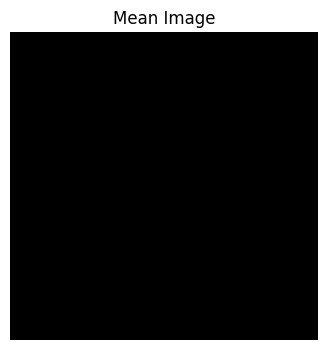

(4900, 3073) (1000, 3073) (1000, 3073)


In [6]:
# --- 2.2 ---

mean_image = np.mean(X_train, axis=0)
print(mean_image[:10])

plt.figure(figsize=(4,4))
plt.imshow(mean_image[:3072].reshape((32,32,3)).astype('uint8'))
plt.title('Mean Image')
plt.axis('Off')
plt.show()

X_train -= mean_image
X_val -= mean_image
X_test -= mean_image

# --- 2.3 ---

if X_train.shape[1] == 3072:
  X_train = np.hstack([X_train, np.ones((X_train.shape[0], 1))])
  X_val = np.hstack([X_val, np.ones((X_val.shape[0], 1))])
  X_test = np.hstack([X_test, np.ones((X_test.shape[0], 1))])

print(X_train.shape, X_val.shape, X_test.shape)

2.4 Реализуйте loss-функции в scripts/classifiers/linear_svm.py



In [9]:
from builtins import range
import numpy as np
from random import shuffle
from past.builtins import xrange

def svm_loss_naive(W, X, y, reg):
    """
    Structured SVM loss function, naive implementation (with loops).

    Inputs have dimension D, there are C classes, and we operate on minibatches
    of N examples.

    Inputs:
    - W: A numpy array of shape (D, C) containing weights.
    - X: A numpy array of shape (N, D) containing a minibatch of data.
    - y: A numpy array of shape (N,) containing training labels; y[i] = c means
      that X[i] has label c, where 0 <= c < C.
    - reg: (float) regularization strength

    Returns a tuple of:
    - loss as single float
    - gradient with respect to weights W; an array of same shape as W
    """
    dW = np.zeros(W.shape) # initialize the gradient as zero

    # compute the loss and the gradient
    num_classes = W.shape[1]
    num_train = X.shape[0]
    loss = 0.0
    for i in range(num_train):
        scores = X[i].dot(W)
        correct_class_score = scores[y[i]]
        for j in range(num_classes):
            if j == y[i]:
                continue
            margin = scores[j] - correct_class_score + 1 # note delta = 1
            if margin > 0:
                loss += margin

                # градиент для неправильного класса (j != y[i])
                dW[:, j] += X[i]

                # градиент для правильного класса (y[i])
                dW[:, y[i]] -= X[i]

    # Right now the loss is a sum over all training examples, but we want it
    # to be an average instead so we divide by num_train.
    loss /= num_train

    # Add regularization to the loss.
    loss += reg * np.sum(W * W)

    dW += 2 * reg * W

    return loss, dW


def svm_loss_vectorized(W, X, y, reg):
    """
    Structured SVM loss function, vectorized implementation.

    Inputs and outputs are the same as svm_loss_naive.
    """
    loss = 0.0
    dW = np.zeros(W.shape) # initialize the gradient as zero

    num_train = X.shape[0]

    ###############################################
    # вычисление функции потерь
    ###############################################

    scores = X.dot(W)

    # извлечение оценок правильного класса для каждого объекта
    correct_class_scores = scores[np.arange(num_train), y].reshape(-1, 1)

    # вычисление отступов для всех классов
    margins = np.maximum(0, scores - correct_class_scores + 1)

    # обнуляем отступы для правильных классов
    margins[np.arange(num_train), y] = 0

    # суммируем потери и усредняем
    loss = np.sum(margins) / num_train

    # добавляем L2 регуляризацию
    loss += reg * np.sum(W * W)

    ###############################################
    # вычисление градиента (Gradient dW)
    ###############################################

    binary_margins = np.zeros(margins.shape)
    binary_margins[margins > 0] = 1

    # Для каждого объекта считаем количество классов, где margin > 0
    row_sum = np.sum(binary_margins, axis=1)

    # Для правильного класса вычитаем количество нарушенных отступов
    binary_margins[np.arange(num_train), y] = -row_sum

    # Градиент dW = X.T @ binary_margins
    dW = X.T.dot(binary_margins)

    # Усредняем градиент и добавляем градиент регуляризации
    dW /= num_train
    dW += 2 * reg * W

    return loss, dW

In [10]:
import time

W = np.random.randn(3073, 10) * 0.0001

loss, grad = svm_loss_naive(W, X_dev, y_dev, 0.000005)
print('loss: %f' % (loss, ))

loss: 9.183088



2.5 Убедитесь, что вы верно реализовали расчет градиента, сравнив с реализацией численными методами (код приведен ниже).

In [11]:
def grad_check_sparse(f, x, analytic_grad, num_checks=10, h=1e-5):
    """
    sample a few random elements and only return numerical
    in this dimensions.
    """
    from random import randrange

    for i in range(num_checks):
        ix = tuple([randrange(m) for m in x.shape])

        oldval = x[ix]
        x[ix] = oldval + h # increment by h
        fxph = f(x) # evaluate f(x + h)
        x[ix] = oldval - h # increment by h
        fxmh = f(x) # evaluate f(x - h)
        x[ix] = oldval # reset

        grad_numerical = (fxph - fxmh) / (2 * h)
        grad_analytic = analytic_grad[ix]
        rel_error = (abs(grad_numerical - grad_analytic) /
                    (abs(grad_numerical) + abs(grad_analytic)))
        print('numerical: %f analytic: %f, relative error: %e'
              %(grad_numerical, grad_analytic, rel_error))

In [12]:
loss, grad = svm_loss_naive(W, X_dev, y_dev, 0.0)

f = lambda w: svm_loss_naive(w, X_dev, y_dev, 0.0)[0]
grad_numerical = grad_check_sparse(f, W, grad)


loss, grad = svm_loss_naive(W, X_dev, y_dev, 5e1)
f = lambda w: svm_loss_naive(w, X_dev, y_dev, 5e1)[0]
grad_numerical = grad_check_sparse(f, W, grad)

numerical: 8.309011 analytic: 4154.505510, relative error: 9.960080e-01
numerical: -17.753953 analytic: -8876.976327, relative error: 9.960080e-01
numerical: 29.642890 analytic: 14821.444898, relative error: 9.960080e-01
numerical: 10.506609 analytic: 5253.304490, relative error: 9.960080e-01
numerical: 2.840042 analytic: 1420.020816, relative error: 9.960080e-01
numerical: 10.514593 analytic: 5257.296327, relative error: 9.960080e-01
numerical: 24.688540 analytic: 12344.270000, relative error: 9.960080e-01
numerical: 12.699625 analytic: 6349.812653, relative error: 9.960080e-01
numerical: 4.448196 analytic: 2224.097959, relative error: 9.960080e-01
numerical: 37.248904 analytic: 18624.452245, relative error: 9.960080e-01
numerical: -10.284269 analytic: -5151.104881, relative error: 9.960149e-01
numerical: -2.750954 analytic: -1384.069311, relative error: 9.960327e-01
numerical: 8.676524 analytic: 4348.777091, relative error: 9.960176e-01
numerical: -9.415375 analytic: -4704.611877, re

2.6 Сравните svm_loss_naive и svm_loss_vectorized реализации

In [13]:
tic = time.time()
_, grad_naive = svm_loss_naive(W, X_dev, y_dev, 0.000005)
toc = time.time()
print('Naive loss and gradient: computed in %fs' % (toc - tic))

tic = time.time()
_, grad_vectorized = svm_loss_vectorized(W, X_dev, y_dev, 0.000005)
toc = time.time()
print('Vectorized loss and gradient: computed in %fs' % (toc - tic))

difference = np.linalg.norm(grad_naive - grad_vectorized, ord='fro')
print('difference: %f' % difference)

Naive loss and gradient: computed in 0.065089s
Vectorized loss and gradient: computed in 0.011618s
difference: 1656844.268092


2.7 Реализуйте стохастический градиентный спуск в /classifiers/linear_classifier.py . Реализуйте методы train() и predict() и запустите следующий код

In [14]:
from __future__ import print_function

from builtins import range
from builtins import object
from past.builtins import xrange

class LinearClassifier(object):

    def __init__(self):
        self.W = None

    def train(self, X, y, learning_rate=1e-3, reg=1e-5, num_iters=100,
              batch_size=200, verbose=False):
        """
        Train this linear classifier using stochastic gradient descent.

        Inputs:
        - X: A numpy array of shape (N, D) containing training data; there are N
          training samples each of dimension D.
        - y: A numpy array of shape (N,) containing training labels; y[i] = c
          means that X[i] has label 0 <= c < C for C classes.
        - learning_rate: (float) learning rate for optimization.
        - reg: (float) regularization strength.
        - num_iters: (integer) number of steps to take when optimizing
        - batch_size: (integer) number of training examples to use at each step.
        - verbose: (boolean) If true, print progress during optimization.

        Outputs:
        A list containing the value of the loss function at each training iteration.
        """

        num_train, dim = X.shape
        num_classes = np.max(y) + 1 # assume y takes values 0...K-1 where K is number of classes
        if self.W is None:
            # lazily initialize W
            self.W = 0.001 * np.random.randn(dim, num_classes)

        # Run stochastic gradient descent to optimize W
        loss_history = []
        for it in range(num_iters):
            X_batch = None
            y_batch = None

            # Генерируем случайные индексы для мини-батча с повторением (replace=True)
            batch_indices = np.random.choice(num_train, batch_size, replace=True)
            X_batch = X[batch_indices]
            y_batch = y[batch_indices]

            # evaluate loss and gradient
            loss, grad = self.loss(X_batch, y_batch, reg)
            loss_history.append(loss)

            # Шаг градиентного спуска: W = W - learning_rate * dW
            self.W -= learning_rate * grad

            if verbose and it % 100 == 0:
                print('iteration %d / %d: loss %f' % (it, num_iters, loss))

        return loss_history

    def predict(self, X):
        """
        Use the trained weights of this linear classifier to predict labels for
        data points.

        Inputs:
        - X: A numpy array of shape (N, D) containing training data; there are N
          training samples each of dimension D.

        Returns:
        - y_pred: Predicted labels for the data in X. y_pred is a 1-dimensional
          array of length N, and each element is an integer giving the predicted
          class.
        """
        y_pred = np.zeros(X.shape[0])

        # Вычисляем скоры для всех классов: (N, D) @ (D, C) -> (N, C)
        scores = X.dot(self.W)
        # Выбираем класс с максимальным значением оценки для каждого объекта
        y_pred = np.argmax(scores, axis=1)

        return y_pred

    def loss(self, X_batch, y_batch, reg):
        """
        Compute the loss function and its derivative.
        Subclasses will override this.

        Inputs:
        - X_batch: A numpy array of shape (N, D) containing a minibatch of N
          data points; each point has dimension D.
        - y_batch: A numpy array of shape (N,) containing labels for the minibatch.
        - reg: (float) regularization strength.

        Returns: A tuple containing:
        - loss as a single float
        - gradient with respect to self.W; an array of the same shape as W
        """
        pass


class LinearSVM(LinearClassifier):
    """ A subclass that uses the Multiclass SVM loss function """

    def loss(self, X_batch, y_batch, reg):
        return svm_loss_vectorized(self.W, X_batch, y_batch, reg)

In [15]:
svm = LinearSVM()
tic = time.time()
loss_hist = svm.train(X_train, y_train, learning_rate=1e-7, reg=2.5e4,
                      num_iters=1500, verbose=True)
toc = time.time()
print('That took %fs' % (toc - tic))

iteration 0 / 1500: loss 794.807828
iteration 100 / 1500: loss 289.543512
iteration 200 / 1500: loss 108.551802
iteration 300 / 1500: loss 42.384169
iteration 400 / 1500: loss 18.873858
iteration 500 / 1500: loss 10.217070
iteration 600 / 1500: loss 6.958584
iteration 700 / 1500: loss 5.879220
iteration 800 / 1500: loss 4.989170
iteration 900 / 1500: loss 5.296409
iteration 1000 / 1500: loss 5.107757
iteration 1100 / 1500: loss 5.461942
iteration 1200 / 1500: loss 5.044936
iteration 1300 / 1500: loss 5.549064
iteration 1400 / 1500: loss 4.933687
That took 8.649415s


In [16]:
y_train_pred = svm.predict(X_train)
print('training accuracy: %f' % (np.mean(y_train == y_train_pred), ))
y_val_pred = svm.predict(X_val)
print('validation accuracy: %f' % (np.mean(y_val == y_val_pred), ))

training accuracy: 0.403469
validation accuracy: 0.363000


2.8 С помощью кросс-валидации выберите значения параметров скорости обучения и регуляризации. В кросс-валидации используйте обучающую и валидационную выборки. Оцените accuracy на тестовой выборке.

In [17]:
learning_rates = [1e-7, 5e-5]
regularization_strengths = [2.5e4, 5e4]

2.9 Сделайте выводы по второй части задания